In [39]:
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [40]:
if torch.cuda.is_available():
    device_name = "cuda"
elif torch.backends.mps.is_available():
    device_name = "mps"
else:
    device_name = "cpu"
    
print(f'Using device: {device_name}')
device = torch.device(device_name)

Using device: mps


---
## LSTM Analysis (Ania Niedzialek)

**Load Keypoints LSTM Model**

In [41]:
# Load keypoints LSTM model (X,Y,Z version)
ckpt_path = "models/keypoints_division_classifier_xyz.pth"
ckpt = torch.load(ckpt_path, map_location=device_name, weights_only=False)

id2label = ckpt["id2label"]
label2id = ckpt["label2id"]
sequence_length = ckpt["sequence_length"]
input_size = ckpt["input_size"]
num_classes = len(id2label)

# Rebuild the model
class KeypointsLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=0.3 if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        out = self.fc(h_n[-1])
        return out

model = KeypointsLSTM(input_size=input_size, hidden_size=128, num_layers=2, num_classes=num_classes)
model.load_state_dict(ckpt["state_dict"])
model = model.to(device_name).eval()

**Load Keypoints Test Data**

In [42]:
# Load keypoints test data
labels_df = pd.read_csv("../data/hp.csv")

keypoints_sequences = []
true_labels = []

KEYPOINTS_DIR = Path("../data/keypoints_1")

for idx, row in labels_df.iterrows():
    folder_name = f"{row['division']}_{row['id']}"
    keypoints_file = KEYPOINTS_DIR / row['division'] / folder_name / "keypoints.npy"
    
    if keypoints_file.exists():
        keypoints = np.load(keypoints_file)
        keypoints_sequences.append(keypoints)
        true_labels.append(label2id[row['division']])

**Preprocess Keypoints for Prediction**

In [43]:
def preprocess_keypoints_sequence(keypoints, target_length):
    """Preprocess keypoints sequence for model input"""
    keypoints = keypoints.astype(np.float32)  # (frames, keypoints, 4)
    
    # Use X,Y,Z coordinates (first 3 dimensions): (frames, keypoints, 3)
    keypoints = keypoints[:, :, :3]
    
    # Flatten keypoints: (frames, keypoints*3)
    keypoints = keypoints.reshape(keypoints.shape[0], -1)
    
    if keypoints.shape[0] >= target_length:
        # Take consecutive frames from the middle
        start_idx = (keypoints.shape[0] - target_length) // 2
        keypoints = keypoints[start_idx:start_idx + target_length]
    else:
        # Pad with repeat
        repeat_times = (target_length + keypoints.shape[0] - 1) // keypoints.shape[0]
        keypoints = np.tile(keypoints, (repeat_times, 1))[:target_length]
    
    return torch.tensor(keypoints).unsqueeze(0)  # Add batch dimension

**Making Predictions with Keypoints**

In [44]:
# Make predictions on keypoints data
preds = []
confidences = []

with torch.no_grad():
    for keypoints_seq in keypoints_sequences:
        x = preprocess_keypoints_sequence(keypoints_seq, sequence_length).to(device_name)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        
        pred = logits.argmax(1).item()
        conf = probs.max().item()
        
        preds.append(pred)
        confidences.append(conf)

preds = np.array(preds)
confidences = np.array(confidences)
true_labels = np.array(true_labels)

print(f"Predictions: {preds}")
print(f"True labels: {true_labels}")
print(f"Average confidence: {np.mean(confidences):.3f}")

Predictions: [3 3 1 2 0 0 0 4 1 1 4 1 0 0 1 0 3 0 3]
True labels: [4 4 4 3 3 0 0 3 3 0 0 3 0 0 3 3 3 3 3]
Average confidence: 0.702


Confusion Matrix

<Figure size 600x500 with 0 Axes>

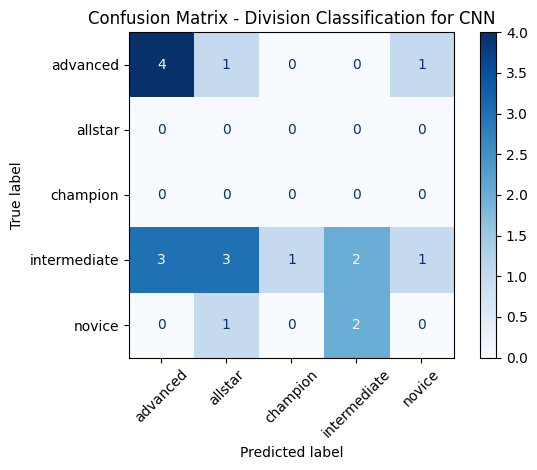

In [45]:

classes = sorted(id2label.keys()) 
cm = confusion_matrix(true_labels, preds, labels=classes)

display_labels = [id2label[c] for c in classes]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
plt.figure(figsize=(6,5))

disp.plot(cmap='Blues', values_format="d", xticks_rotation=45)

if cm.max() == cm.min():
    disp.im_.set_clim(0, cm.max() + 1)

plt.title("Confusion Matrix - Division Classification for CNN")
plt.tight_layout()
plt.show()

Misclassified Examples

In [46]:
# Misclassified Examples Analysis
mis_idx = [i for i in range(len(preds)) if preds[i] != true_labels[i]]

print("Number of misclassified examples:", len(mis_idx))
print(f"Overall accuracy: {len(preds) - len(mis_idx)}/{len(preds)} = {(len(preds) - len(mis_idx))/len(preds):.3f}")

# Show misclassification details
if mis_idx:
    print("\nMisclassification details:")
    for i in mis_idx[:5]:  # Show first 5 examples
        true_div = id2label[true_labels[i]]
        pred_div = id2label[preds[i]]
        conf = confidences[i]
        print(f"  Sample {i}: True={true_div:12} | Pred={pred_div:12} | Conf={conf:.3f}")
else:
    print("All predictions were correct!")

Number of misclassified examples: 13
Overall accuracy: 6/19 = 0.316

Misclassification details:
  Sample 0: True=novice       | Pred=intermediate | Conf=0.671
  Sample 1: True=novice       | Pred=intermediate | Conf=0.482
  Sample 2: True=novice       | Pred=allstar      | Conf=0.472
  Sample 3: True=intermediate | Pred=champion     | Conf=0.452
  Sample 4: True=intermediate | Pred=advanced     | Conf=0.504


**LSTM Analysis - Temporal Importance Visualization**

In [47]:
# For LSTM models, we analyze temporal importance instead of spatial heatmaps
def analyze_temporal_importance(keypoints_seq, model, sequence_length):
    """Analyze which time steps are most important for the LSTM's decision"""
    model.eval()
    
    # Preprocess the sequence
    x = preprocess_keypoints_sequence(keypoints_seq, sequence_length).to(device_name)
    
    # Get LSTM outputs for each time step
    with torch.no_grad():
        # Get LSTM hidden states for all time steps
        lstm_out, (h_n, c_n) = model.lstm(x)
        
        # Get classification weights
        fc_weights = model.fc.weight.data  # (num_classes, hidden_size)
        
        # Calculate importance scores for each time step
        # Importance = |output · weight| for the predicted class
        pred_class = model(x).argmax(1).item()
        class_weights = fc_weights[pred_class]  # (hidden_size,)
        
        # Calculate importance per time step
        importance_scores = []
        for t in range(lstm_out.shape[1]):  # for each time step
            timestep_output = lstm_out[0, t, :]  # (hidden_size,)
            importance = torch.abs(torch.dot(timestep_output, class_weights)).item()
            importance_scores.append(importance)
        
        # Normalize importance scores
        importance_scores = np.array(importance_scores)
        importance_scores = importance_scores / (importance_scores.max() + 1e-8)
        
    return importance_scores

def plot_temporal_importance(keypoints_seq, importance_scores, title="Temporal Importance"):
    """Plot the importance of each time step"""
    plt.figure(figsize=(15, 4))
    
    plt.subplot(1, 3, 1)
    plt.plot(importance_scores, 'b-', linewidth=2)
    plt.xlabel('Time Step')
    plt.ylabel('Importance Score')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    # Show X,Y trajectory (first keypoint)
    keypoints_xy = keypoints_seq[:, :, :2]  # Use only x,y for trajectory
    if keypoints_xy.shape[1] > 0:
        plt.plot(keypoints_xy[:, 0, 0], keypoints_xy[:, 0, 1], 'r-o', markersize=3)
        plt.xlabel('X Coordinate')
        plt.ylabel('Y Coordinate')
        plt.title('Keypoint 0 Trajectory (X,Y)')
        plt.axis('equal')
        plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 3)
    # Show Z movement (first keypoint)
    keypoints_z = keypoints_seq[:, :, 2]  # Z coordinate only
    if keypoints_z.shape[1] > 0:
        plt.plot(keypoints_z[:, 0], 'g-o', markersize=3)
        plt.xlabel('Time Step')
        plt.ylabel('Z Coordinate')
        plt.title('Keypoint 0 Z Movement')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

**Visualize Temporal Importance for Examples**

=== CORRECT PREDICTION ANALYSIS ===
Example 5: True=advanced, Pred=advanced, Conf=0.542


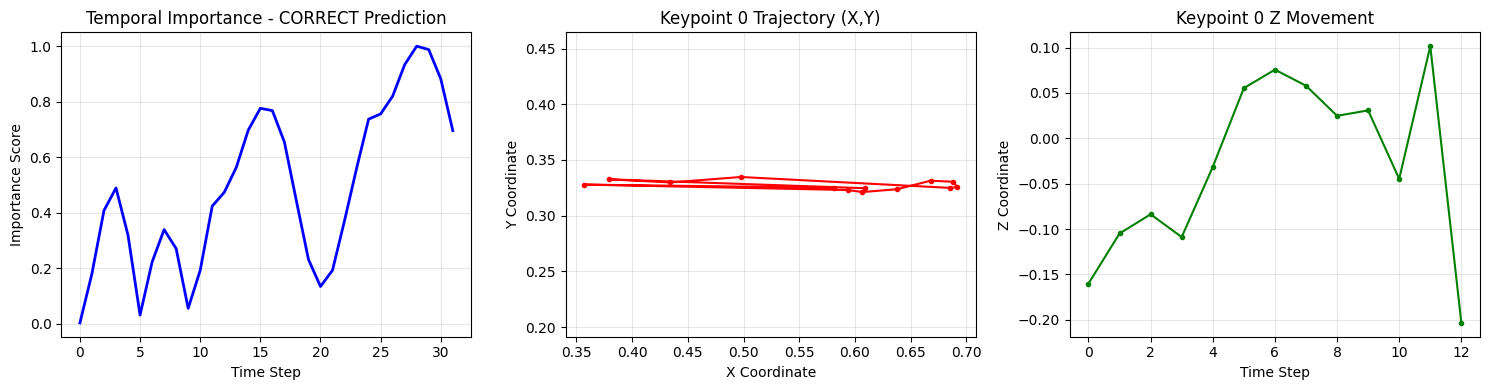


=== INCORRECT PREDICTION ANALYSIS ===
Example 0: True=novice, Pred=intermediate, Conf=0.671


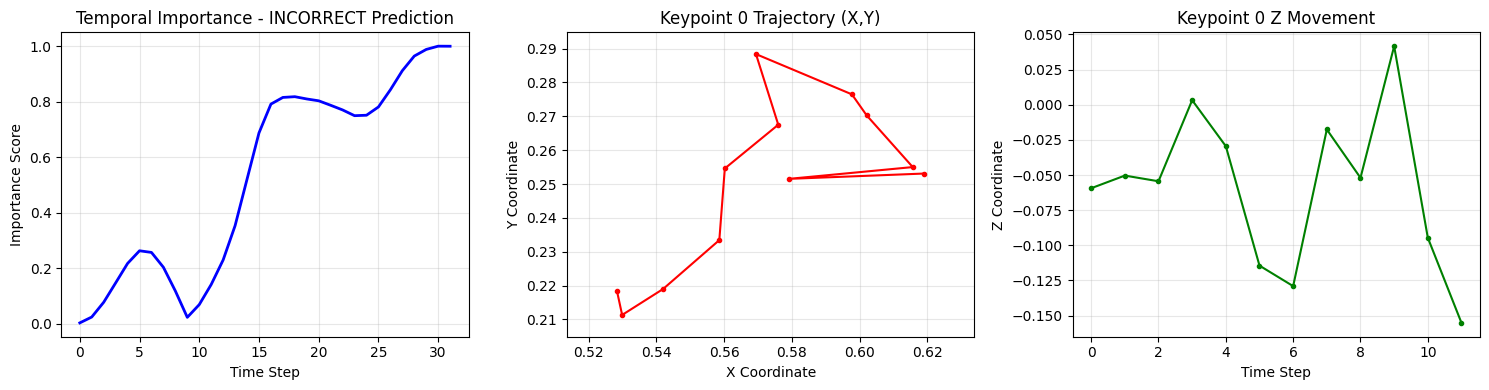

In [48]:
def analyze_example(idx):
    """Analyze temporal importance for a specific example"""
    keypoints_seq = keypoints_sequences[idx]
    true_label = id2label[true_labels[idx]]
    pred_label = id2label[preds[idx]]
    confidence = confidences[idx]
    
    print(f"Example {idx}: True={true_label}, Pred={pred_label}, Conf={confidence:.3f}")
    
    # Analyze temporal importance
    importance_scores = analyze_temporal_importance(keypoints_seq, model, sequence_length)
    
    # Plot results
    is_correct = true_labels[idx] == preds[idx]
    status = "CORRECT" if is_correct else "INCORRECT"
    plot_temporal_importance(keypoints_seq, importance_scores, 
                           f"Temporal Importance - {status} Prediction")

# Analyze a correct prediction
correct_indices = [i for i in range(len(preds)) if preds[i] == true_labels[i]]
if correct_indices:
    print("=== CORRECT PREDICTION ANALYSIS ===")
    analyze_example(correct_indices[0])

# Analyze an incorrect prediction  
incorrect_indices = [i for i in range(len(preds)) if preds[i] != true_labels[i]]
if incorrect_indices:
    print("\n=== INCORRECT PREDICTION ANALYSIS ===")
    analyze_example(incorrect_indices[0])

**Analyze Multiple Examples**

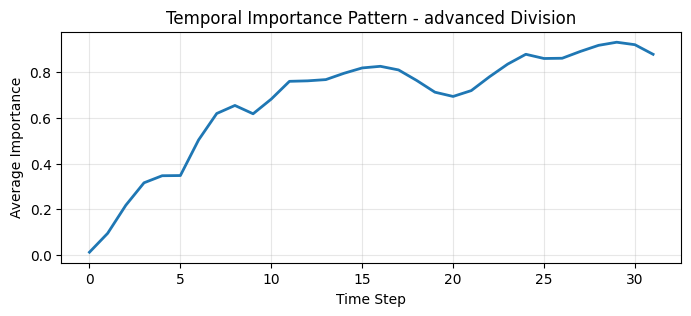

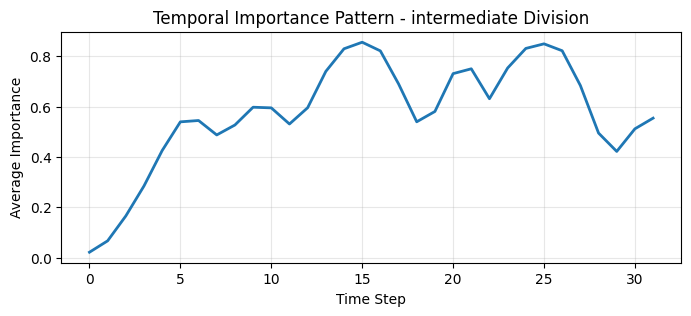

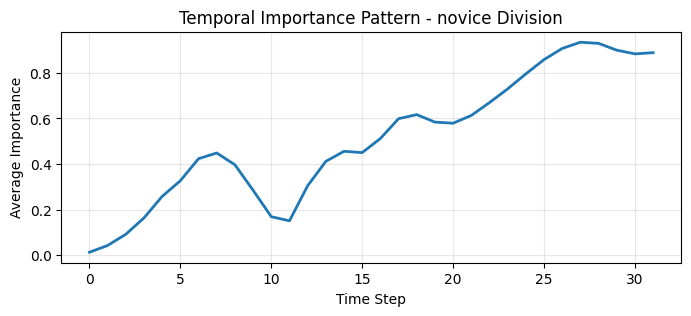

Division-specific temporal analysis complete!


In [49]:
# Analyze temporal patterns for different divisions
division_analysis = {}

for division in id2label.values():
    division_indices = [i for i in range(len(true_labels)) if id2label[true_labels[i]] == division]
    if division_indices:
        # Collect importance scores for this division
        all_importance = []
        for idx in division_indices[:3]:  # Analyze first 3 examples per division
            importance = analyze_temporal_importance(keypoints_sequences[idx], model, sequence_length)
            all_importance.append(importance)
        
        # Average importance pattern for this division
        avg_importance = np.mean(all_importance, axis=0)
        division_analysis[division] = avg_importance
        
        plt.figure(figsize=(8, 3))
        plt.plot(avg_importance, linewidth=2, label=f'{division} (n={len(division_indices)})')
        plt.xlabel('Time Step')
        plt.ylabel('Average Importance')
        plt.title(f'Temporal Importance Pattern - {division} Division')
        plt.grid(True, alpha=0.3)
        plt.show()

print("Division-specific temporal analysis complete!")

**Division-Level Performance Analysis**

=== Division-Level Performance ===
advanced: 0.667 accuracy (6 samples)
intermediate: 0.200 accuracy (10 samples)
novice: 0.000 accuracy (3 samples)


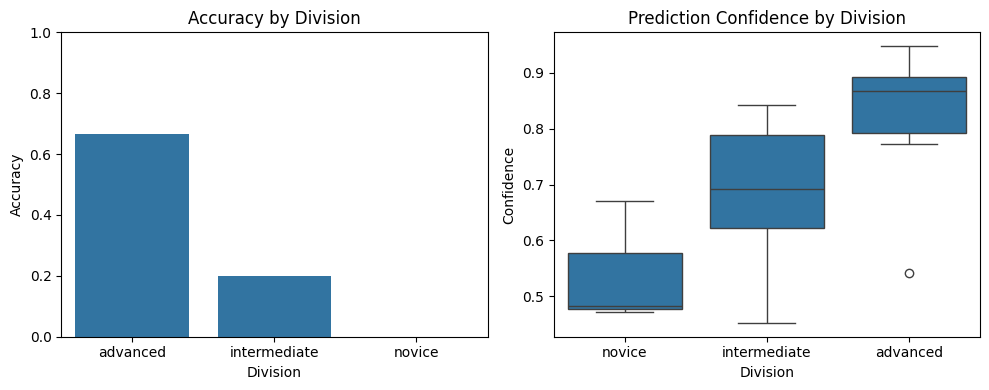


=== Overall Performance ===
Overall Accuracy: 0.316
Average Confidence: 0.702


In [50]:
# Create a DataFrame for sequence-level results
results_df = pd.DataFrame({
    "true_label": true_labels,
    "pred": preds,
    "confidence": confidences,
    "sequence_idx": range(len(preds))
})

# Add division names
results_df["true_division"] = results_df["true_label"].apply(lambda x: id2label[x])
results_df["pred_division"] = results_df["pred"].apply(lambda x: id2label[x])
results_df["correct"] = results_df["true_label"] == results_df["pred"]

# Calculate accuracy per division
division_acc = results_df.groupby("true_division")["correct"].mean()
division_counts = results_df.groupby("true_division").size()

print("=== Division-Level Performance ===")
for division in division_acc.index:
    acc = division_acc[division]
    count = division_counts[division]
    print(f"{division}: {acc:.3f} accuracy ({count} samples)")

plt.figure(figsize=(10, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
sns.barplot(x=division_acc.index, y=division_acc.values)
plt.title("Accuracy by Division")
plt.ylabel("Accuracy")
plt.xlabel("Division")
plt.ylim(0, 1)

# Confidence plot
plt.subplot(1, 2, 2)
sns.boxplot(data=results_df, x="true_division", y="confidence")
plt.title("Prediction Confidence by Division")
plt.ylabel("Confidence")
plt.xlabel("Division")

plt.tight_layout()
plt.show()

print("\n=== Overall Performance ===")
overall_acc = results_df["correct"].mean()
avg_confidence = results_df["confidence"].mean()
print(f"Overall Accuracy: {overall_acc:.3f}")
print(f"Average Confidence: {avg_confidence:.3f}")

---
## Decision Tree Analysis (Nguyen Pham)

In [51]:
# =====================================================
# Decision Tree Analysis - Load Model and Data
# =====================================================

import joblib
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import math

# Paths
DT_MODEL_PATH = Path("../data/processed/decision_tree_classifier.joblib")
DT_DATA_DIR = Path('../data/keypoints_1')
DT_LABELS_CSV = Path('../data/hp.csv')

# Load the saved Decision Tree model
dt_pipe = joblib.load(DT_MODEL_PATH)
print(f"Loaded Decision Tree model from {DT_MODEL_PATH}")

# =====================================================
# Helper functions for loading and preprocessing
# =====================================================

def dt_load_labels_mapping():
    if not DT_LABELS_CSV.exists():
        return None
    df = pd.read_csv(DT_LABELS_CSV)
    mapping = {}
    for _, row in df.iterrows():
        video_name = f"{row['division']}_{row['id']}"
        mapping[video_name] = row['labels']
    return mapping

def dt_find_videos(root=DT_DATA_DIR):
    records = []
    if not root.exists():
        raise FileNotFoundError(f"Data dir not found: {root}")
    
    labels_mapping = dt_load_labels_mapping()
    
    for label_dir in sorted(root.iterdir()):
        if not label_dir.is_dir():
            continue
        division = label_dir.name
        
        for video_dir in sorted(label_dir.iterdir()):
            if not video_dir.is_dir():
                continue
            
            np_path = video_dir / 'keypoints.npy'
            if not np_path.exists():
                continue
            
            video_name = video_dir.name
            trick_label = labels_mapping.get(video_name, division) if labels_mapping else division
            
            records.append({
                'label': trick_label,
                'division': division,
                'video': video_name,
                'np_path': np_path,
            })
    
    return pd.DataFrame(records)

def dt_load_keypoints(np_path):
    arr = np.load(np_path)
    return arr.astype(np.float32)

def interpolate_missing(arr, visibility_threshold=0.1):
    out = arr.copy()
    for lm in range(out.shape[1]):
        vis = out[:, lm, 3]
        bad = vis < visibility_threshold
        if bad.all():
            continue
        for d in range(3):
            vals = out[:, lm, d].astype(float)
            vals[bad] = np.nan
            s = pd.Series(vals)
            vals_filled = s.interpolate(limit_direction='both').bfill().ffill().values
            out[:, lm, d] = vals_filled.astype(np.float32)
    return out

def torso_scale_single(lm):
    left_sh = lm[11][:2]
    right_sh = lm[12][:2]
    left_hip = lm[23][:2]
    right_hip = lm[24][:2]
    mid_sh = (left_sh + right_sh) / 2.0
    mid_hip = (left_hip + right_hip) / 2.0
    d = np.linalg.norm(mid_sh - mid_hip)
    return max(d, 1e-6)

def normalize_by_torso(arr):
    out = arr.copy()
    for t in range(out.shape[0]):
        lm = out[t]
        hip_center = (lm[23][:2] + lm[24][:2]) / 2.0
        scale = torso_scale_single(lm)
        out[t, :, :2] = (lm[:, :2] - hip_center) / scale
    return out

def pad_or_truncate(arr, target_len=64, strategy='center'):
    T = arr.shape[0]
    if T == target_len:
        return arr
    if T > target_len:
        if strategy == 'center':
            start = max(0, (T - target_len) // 2)
            return arr[start:start+target_len]
        return arr[:target_len]
    pad = np.zeros((target_len - T, arr.shape[1], arr.shape[2]), dtype=arr.dtype)
    return np.concatenate([arr, pad], axis=0)

def angle_at(a, b, c):
    ba = a - b
    bc = c - b
    lena = np.linalg.norm(ba)
    lenb = np.linalg.norm(bc)
    if lena < 1e-6 or lenb < 1e-6:
        return 0.0
    cosang = np.dot(ba, bc) / (lena * lenb)
    cosang = np.clip(cosang, -1.0, 1.0)
    return math.acos(cosang)

ANGLE_TRIPLETS = [(11, 13, 15), (12, 14, 16), (23, 25, 27), (24, 26, 28)]

def compute_frame_features(seq):
    T = seq.shape[0]
    flat = seq[:, :, :3].reshape(T, -1)
    
    angles = np.zeros((T, len(ANGLE_TRIPLETS)), dtype=np.float32)
    for t in range(T):
        for i, (a, b, c) in enumerate(ANGLE_TRIPLETS):
            angles[t, i] = angle_at(seq[t, a, :2], seq[t, b, :2], seq[t, c, :2])
    
    important = [11, 12, 23, 24, 13, 14, 25, 26]
    pdists = []
    for t in range(T):
        coords = seq[t, important, :2]
        dists = []
        for i in range(coords.shape[0]):
            for j in range(i+1, coords.shape[0]):
                dists.append(np.linalg.norm(coords[i] - coords[j]))
        pdists.append(dists)
    pdists = np.array(pdists)
    
    vel = np.vstack((np.zeros((1, flat.shape[1])), np.diff(flat, axis=0)))
    feats = np.concatenate([flat, angles, pdists, vel], axis=1)
    return feats

def aggregate_video_features(seq, target_len=64):
    seq = interpolate_missing(seq)
    seq = normalize_by_torso(seq)
    seq = pad_or_truncate(seq, target_len=target_len)
    
    frame_feats = compute_frame_features(seq)
    mean = frame_feats.mean(axis=0)
    std = frame_feats.std(axis=0)
    
    return np.concatenate([mean, std])

# =====================================================
# Load data and build feature matrix
# =====================================================

dt_df = dt_find_videos()
print(f"Found {len(dt_df)} videos")

# Build feature matrix
dt_X = []
dt_y = []
dt_meta_records = []

for _, r in dt_df.iterrows():
    seq = dt_load_keypoints(r['np_path'])
    vec = aggregate_video_features(seq, target_len=64)
    dt_X.append(vec)
    dt_y.append(r['label'])
    dt_meta_records.append({
        'label': r['label'],
        'division': r.get('division', ''),
        'video': r['video'],
    })

dt_X = np.array(dt_X)
dt_y = np.array(dt_y)
dt_meta = pd.DataFrame(dt_meta_records)

# Filter for target classes (sugar_push and sugar_tag)
target_classes = ['sugar_push', 'sugar_tag']
mask = np.isin(dt_y, target_classes)
dt_X = dt_X[mask]
dt_y = dt_y[mask]
dt_meta = dt_meta[mask].reset_index(drop=True)

Loaded Decision Tree model from ../data/processed/decision_tree_classifier.joblib
Found 19 videos


**Decision Tree - Dimensionality Reduction and Visualization**

In [52]:
def do_dimensionality_reduction(X, n_pca=10):
    n_samples, n_features = X.shape
    print(f'Running PCA -> t-SNE (n_samples={n_samples}, n_features={n_features})...')

    pca_components = max(2, min(n_pca, n_samples, n_features))
    pca = PCA(n_components=pca_components, random_state=0)
    X_pca = pca.fit_transform(X)

    if n_samples < 3:
        print('Too few samples for t-SNE (need >=3). Returning PCA only.')
        return {'pca': X_pca}

    perplexity = min(30, max(2, (n_samples - 1) // 3))
    perplexity = min(perplexity, n_samples - 1)
    
    try:
        tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate='auto', init='pca', random_state=0)
        X_tsne = tsne.fit_transform(X_pca[:, :pca_components])
    except Exception as exc:
        print('t-SNE failed:', exc)
        X_tsne = None
    
    return {'pca': X_pca, 'tsne': X_tsne}

# Standardize and reduce dimensions
dt_Xs = StandardScaler().fit_transform(dt_X)
dt_emb = do_dimensionality_reduction(dt_X)

if 'tsne' in dt_emb and dt_emb['tsne'] is not None:
    dt_emb_plot = dt_emb['tsne']
    dt_method = 't-SNE'
else:
    dt_emb_plot = dt_emb['pca'][:, :2]
    dt_method = 'PCA'

print(f'Using {dt_method} for visualization')

Running PCA -> t-SNE (n_samples=19, n_features=460)...
Using t-SNE for visualization


**Decision Tree - 2D Feature Space Plot**

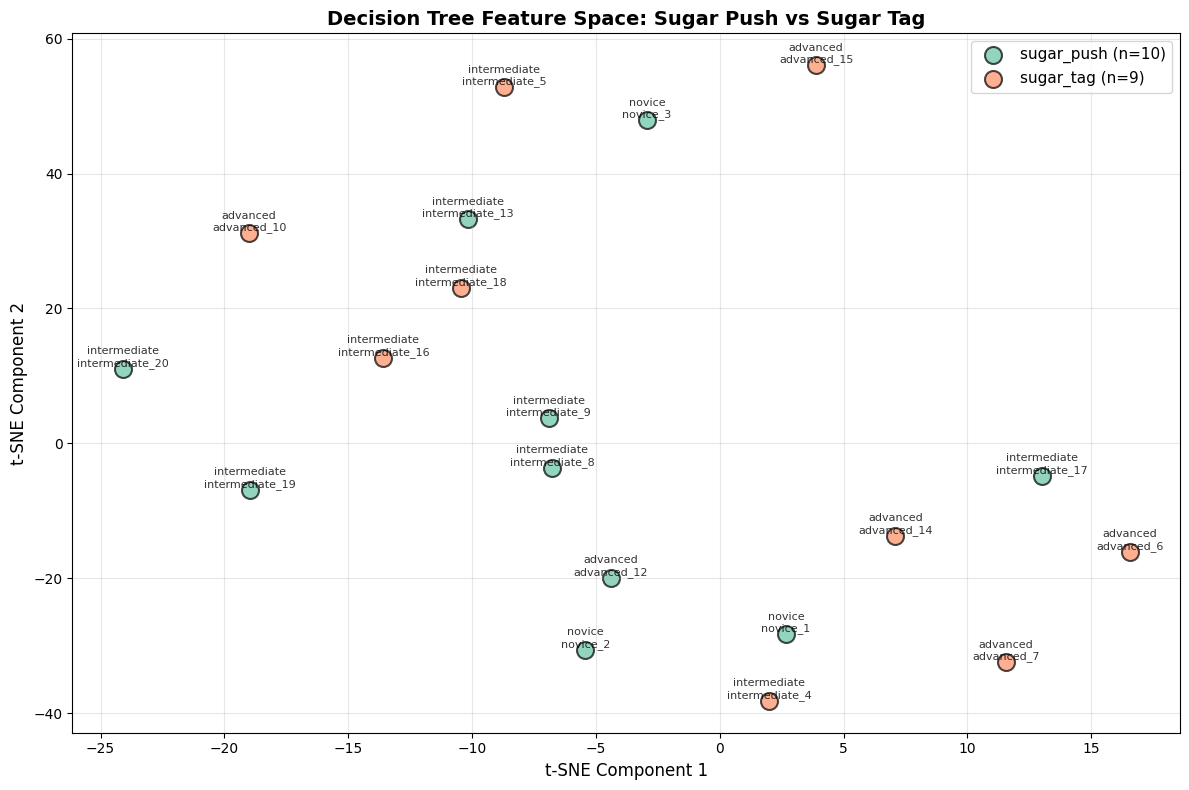

In [53]:
plt.figure(figsize=(12, 8))
unique_labels = np.unique(dt_y)
colors = sns.color_palette('Set2', n_colors=len(unique_labels))
label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

for label in unique_labels:
    mask = dt_y == label
    indices = np.where(mask)[0]
    
    plt.scatter(
        dt_emb_plot[mask, 0],
        dt_emb_plot[mask, 1],
        label=f'{label} (n={mask.sum()})',
        s=150,
        alpha=0.7,
        color=label_to_color[label],
        edgecolors='black',
        linewidth=1.5
    )
    
    for idx in indices:
        division = dt_meta.iloc[idx]['division']
        video = dt_meta.iloc[idx]['video']
        plt.annotate(
            f"{division}\n{video}",
            (dt_emb_plot[idx, 0], dt_emb_plot[idx, 1]),
            fontsize=8,
            alpha=0.8,
            ha='center',
            va='bottom'
        )

plt.xlabel(f'{dt_method} Component 1', fontsize=12)
plt.ylabel(f'{dt_method} Component 2', fontsize=12)
plt.title('Decision Tree Feature Space: Sugar Push vs Sugar Tag', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Decision Tree - Predict**

In [54]:
# Load the full dataset using keypoints_2
df_test = dt_find_videos()  

# Make predictions on all data
all_predictions = []
all_true_labels = []
prediction_probs = []

for _, row in df_test.iterrows():
    # Load and preprocess the video
    seq = dt_load_keypoints(row['np_path'])
    vec = aggregate_video_features(seq, target_len=64)
    
    # Predict
    pred = dt_pipe.predict([vec])[0]
    prob = dt_pipe.predict_proba([vec])[0]
    
    all_predictions.append(pred)
    all_true_labels.append(row['label'])
    prediction_probs.append(prob)

# Calculate overall accuracy
all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)
overall_accuracy = accuracy_score(all_true_labels, all_predictions)

# Print results
print(f"Total samples tested: {len(all_predictions)}")
print(f"Overall Accuracy: {overall_accuracy:.2%}")

Total samples tested: 19
Overall Accuracy: 100.00%
